In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143
Total spikes in AP: 431640.0


R_stim4 shape: (33, 30)
R_catch shape: (143, 30)
CD shape: (30,)


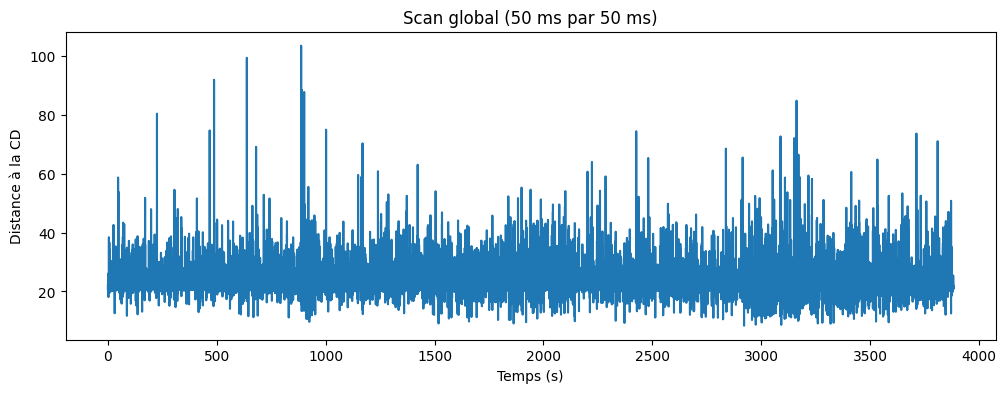

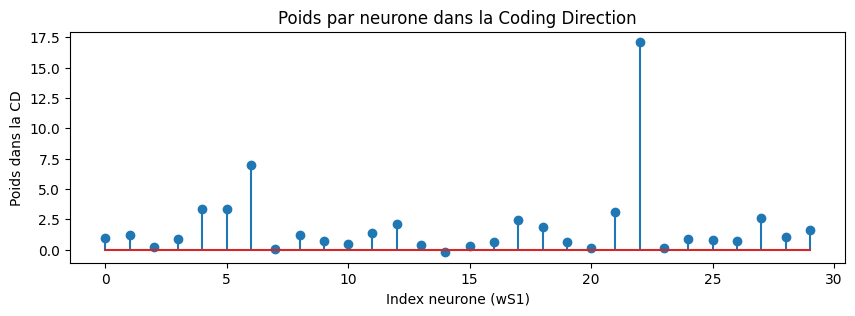

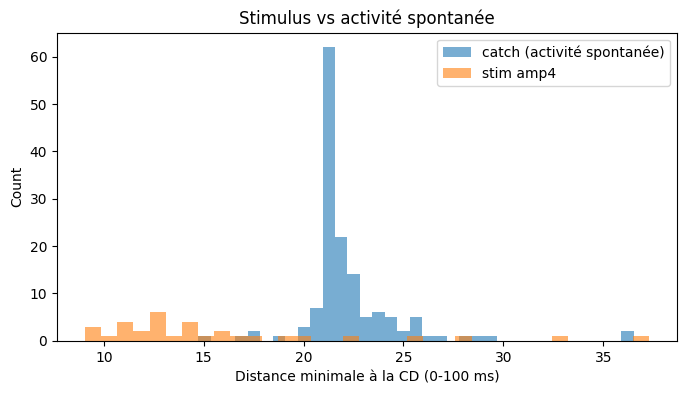

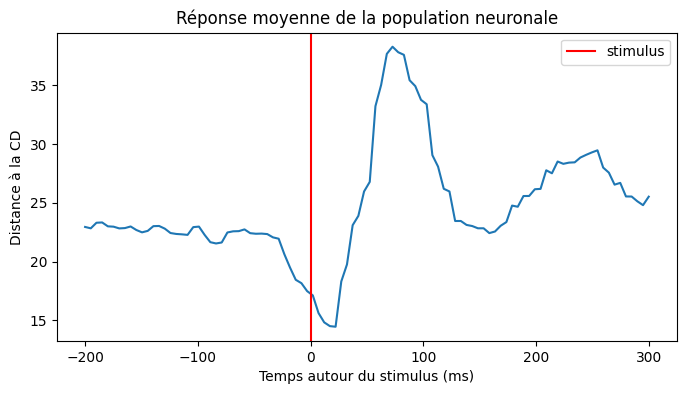

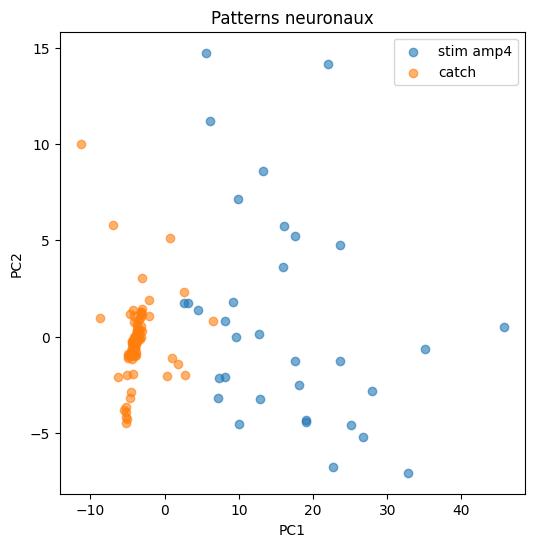

In [10]:
# SUITE DE L'ANALYSE : vecteurs réponse, z-score, CD, distances

from sklearn.decomposition import PCA

# 1) PARAMETRES POUR LA REPONSE
WIN = 0.050                    # 50 ms
WIN_BINS = int(round(WIN / Bin_size))   # ici = 5 bins
EVAL_AFTER = (0.0, 0.05)        # on cherche la meilleure similarité dans 0-50 ms
USE_ZSCORE = True

# 2) EVENTS UTILISES ENSUITE
stim_onsets  = tr.loc[tr["whisker_stim"] == 1, "whisker_stim_time"].to_numpy()
stim_amps    = tr.loc[tr["whisker_stim"] == 1, "whisker_stim_amplitude"].to_numpy()
catch_onsets = tr.loc[tr["no_stim"] == 1, "no_stim_time"].to_numpy()

stim_amp4_times = stim_onsets[stim_amps == 4]

# 3) OUTILS
def t_to_bin(t):
    return int(np.floor(t / Bin_size))

def pop_vec(AP, b0, b1):
    """
    Somme des spikes de chaque neurone entre b0 et b1
    -> retourne un vecteur de taille N_neurones
    """
    b0 = max(0, b0)
    b1 = min(AP.shape[1], b1)
    return AP[:, b0:b1].sum(axis=1).astype(float)

def response_vec_from_time(t):
    """
    Réponse d'un event = post(0-50 ms) - baseline(-50-0 ms)
    """
    b = t_to_bin(t)
    post = pop_vec(AP_Bin_Matrx, b, b + WIN_BINS)
    base = pop_vec(AP_Bin_Matrx, b - WIN_BINS, b)
    return post - base

# 4) BASELINE POUR LE Z-SCORE
all_events = np.concatenate([stim_onsets, catch_onsets])

baseline_vectors = []
for t in all_events:
    b = t_to_bin(t)
    base = pop_vec(AP_Bin_Matrx, b - WIN_BINS, b)
    baseline_vectors.append(base)

baseline_vectors = np.vstack(baseline_vectors)

mu_base = baseline_vectors.mean(axis=0)
sd_base = baseline_vectors.std(axis=0) + 1e-9

def zscore(v):
    return (v - mu_base) / sd_base

# 5) MATRICES DE REPONSES
R_stim4 = np.vstack([response_vec_from_time(t) for t in stim_amp4_times])
R_catch = np.vstack([response_vec_from_time(t) for t in catch_onsets])

if USE_ZSCORE:
    R_stim4_use = np.vstack([zscore(v) for v in R_stim4])
    R_catch_use = np.vstack([zscore(v) for v in R_catch])
else:
    R_stim4_use = R_stim4.copy()
    R_catch_use = R_catch.copy()

print("R_stim4 shape:", R_stim4_use.shape)
print("R_catch shape:", R_catch_use.shape)

# 6) CODING DIRECTION
mu_stim4 = R_stim4_use.mean(axis=0)
mu_catch = R_catch_use.mean(axis=0)

CD = mu_stim4 - mu_catch

print("CD shape:", CD.shape)

# 7) SCAN GLOBAL DU SIGNAL
starts = np.arange(0, AP_Bin_Matrx.shape[1] - WIN_BINS + 1, WIN_BINS)
times_center = (starts + WIN_BINS / 2) * Bin_size

distances = np.zeros(len(starts), dtype=float)

for k, b0 in enumerate(starts):
    b1 = b0 + WIN_BINS

    x_post = pop_vec(AP_Bin_Matrx, b0, b1)
    x_base = pop_vec(AP_Bin_Matrx, b0 - WIN_BINS, b0)
    x_resp = x_post - x_base

    if USE_ZSCORE:
        x_use = zscore(x_resp)
    else:
        x_use = x_resp

    distances[k] = np.linalg.norm(x_use - CD)

plt.figure(figsize=(12,4))
plt.plot(times_center, distances)
plt.xlabel("Temps (s)")
plt.ylabel("Distance à la CD")
plt.title("Scan global (50 ms par 50 ms)")
plt.show()

# 8) DISTANCE MINIMALE APRES CHAQUE EVENT
def min_distance_after_event(event_time):
    t0 = event_time + EVAL_AFTER[0]
    t1 = event_time + EVAL_AFTER[1]
    mask = (times_center >= t0) & (times_center < t1)
    if not np.any(mask):
        return np.inf
    return distances[mask].min()

stim_minD = np.array([min_distance_after_event(t) for t in stim_onsets])
catch_minD = np.array([min_distance_after_event(t) for t in catch_onsets])

# 9) FIGURES

# a) Poids de la CD
plt.figure(figsize=(10,3))
plt.stem(CD)
plt.xlabel("Index neurone (wS1)")
plt.ylabel("Poids dans la CD")
plt.title("Poids par neurone dans la Coding Direction")
plt.show()

# b) Histogramme catch vs amp4
plt.figure(figsize=(8,4))
plt.hist(catch_minD, bins=35, alpha=0.6, label="catch (activité spontanée)")
plt.hist(stim_minD[stim_amps == 4], bins=35, alpha=0.6, label="stim amp4")
plt.xlabel("Distance minimale à la CD (0-100 ms)")
plt.ylabel("Count")
plt.title("Stimulus vs activité spontanée")
plt.legend()
plt.show()

# d) Distance moyenne autour du stimulus
window = np.linspace(-0.2, 0.3, 100)
mean_dist = []

for dt in window:
    vals = []
    for t in stim_amp4_times:
        idx = np.argmin(np.abs(times_center - (t + dt)))
        vals.append(distances[idx])
    mean_dist.append(np.mean(vals))

plt.figure(figsize=(8,4))
plt.plot(window * 1000, mean_dist)
plt.axvline(0, color="red", label="stimulus")
plt.xlabel("Temps autour du stimulus (ms)")
plt.ylabel("Distance à la CD")
plt.title("Réponse moyenne de la population neuronale")
plt.legend()
plt.show()

# e) PCA
X = np.vstack([R_stim4_use, R_catch_use])
labels = np.concatenate([
    np.ones(len(R_stim4_use)),
    np.zeros(len(R_catch_use))
])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], alpha=0.6, label="stim amp4")
plt.scatter(X_pca[labels == 0, 0], X_pca[labels == 0, 1], alpha=0.6, label="catch")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patterns neuronaux")
plt.legend()
plt.show()